# NAAIM-Exposure as a contrarian timing signal -- a quantitative teardown 🔬
### Regime sort + HAC *t* · predictive regression (slope, *t*, R²) · cost-charged overlay vs buy-and-hold · a deterministic synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pros_smarter%3F: Not_supported](https://img.shields.io/badge/Pros_smarter%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The NAAIM Exposure Index is **active managers' reported equity exposure** (0-200%), weekly since 2006. We test the contrarian claim -- high exposure predicts weak forward returns, low exposure strong ones -- on the real SPY total-return tape with autocorrelation-robust inference, then ask whether any of it survives costs against buy-and-hold.

> ⚠️ **Not investment advice.** Real data: NAAIM weekly Number (free since-inception spreadsheet, naaim.org) joined to SPY total return (yfinance, `auto_adjust=True`), 1,040 weeks (2006-07-05 -> 2026-06-10); one-week execution lag. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from naaim_exposure import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.build_real_panel() if True else None   # always builds (weekly cache or real fallback)
print("real NAAIM weekly cache present:", HAVE_REAL, "| weeks in panel:", len(PANEL))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2006-07-05 -> 2026-06-10', 'weeks': 1040, 'fp': 'b887999dd648', 'naaim_lo': -3.6, 'naaim_hi': 120.6, 'naaim_mean': 67.3, 'uncond_yr': 12.0, 'uncond_t': 3.42, 'low_yr': 16.2, 'low_t': 1.92, 'low_n': 347, 'mid_yr': 11.3, 'mid_t': 2.15, 'mid_n': 346, 'high_yr': 8.6, 'high_t': 2.49, 'high_n': 347, 'gap_yr': 7.6, 'ls_yr': 2.52, 'ls_t': 0.81, 'beta_sd': -0.04, 'beta_t': -0.4, 'r2': 0.0003, 'ov_yr': 8.68, 'ov_sr': 0.57, 'ov_t': 2.72, 'ov_inmkt': 67, 'bh_yr': 12.04, 'bh_sr': 0.73, 'sub': [('2006-2012', 6.3, 0.34, 1.2, 0.17, 339), ('2013-2019', 22.5, 2.28, 12.2, 2.57, 364), ('2020-2026', 22.0, 1.37, 12.0, 1.54, 337)], 'syn_null_t': -0.37, 'syn_edge': 0.004, 'syn_edge_t': -6.12}


real NAAIM weekly cache present: True | weeks in panel: 1040


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Contrarian *direction* holds (low-exposure +16.2%/yr vs high +8.6%/yr, gap +7.6 pp/yr) but the long-short HAC **t = +0.81** and regression slope **t = -0.40** (R² ≈ 0.03%) are far below 2. |
| **Tradability** | `MIRAGE` | Long/flat contrarian overlay nets **+8.68%/yr** (SR 0.57) vs buy-and-hold **+12.04%/yr** (SR 0.73); sitting out the all-in regime skips the bull-market core. |
| **Pros smarter than retail?** | `NOT SUPPORTED` | Same weak/untradeable tilt as the AAII retail survey ([257](../../257-aaii-sentiment/)). |

> 💡 In plain words: the pros' positioning leans the contrarian way, but it's a weak, pro-cyclical lean -- statistically it's a coin-flip's distance from noise, and as a trade it loses to staying invested because managers go all-in *during* the rallies.

## 1 · The claim, steelmanned

Let $e_t$ be the NAAIM exposure observed at weekly survey $t$ and $r_{t+1}$ the SPY total return over the following week. The contrarian hypotheses:

- **H₁ (signal).** $\mathbb{E}[r_{t+1}\mid e_t\text{ high}] < \mathbb{E}[r_{t+1}\mid e_t\text{ low}]$ -- a *negative* predictive slope, $\beta < 0$ with HAC $|t|\ge 2$.
- **H₂ (tradable).** A long/flat (or long/short) rule keyed on $e_t$ beats buy-and-hold net of one-way costs.
- **H₃ (smart money).** Because $e_t$ is *professional* positioning, the contrarian edge exceeds the equivalent retail-sentiment gauge.

We find **H₁ weakly accepted in sign only** (slope negative but $|t|<1$, R² ≈ 0.03%), **H₂ rejected** (the overlay loses to buy-and-hold), and **H₃ rejected** (no better than AAII). The folklore is directionally true and practically empty.

## 2 · So what? -- what rides on each answer

A free, public, weekly timing signal from the people closest to the market would be a genuine crack in efficiency -- and a deep statement that proximity breeds error at the extremes. But three structural priors push hard the other way: (i) **prediction efficiency** -- a gauge thousands watch shouldn't hide a stable edge; (ii) the **favourite-of-trend** problem -- manager exposure is largely trend-following (Frazzini-Lamont *Dumb Money*), so "fade the all-in pros" ≈ "fade recent strength," a pro-cyclical bet; (iii) the **dividend tax of timing** -- any rule that sits in cash forgoes total return, so the honest benchmark is dividend-reinvested buy-and-hold, which is a high bar. The test must charge all three.

## 3 · How we'd know -- the protocol

- **Real tape.** NAAIM weekly Number (2006-07-05 -> 2026-06-10, 1,040 weeks; fingerprint `b887999dd648`) joined to SPY total-return closes on each survey date; $r_{t+1}$ is the SPY return to the next survey date (one-week lag, applied once).
- **Regime sort.** Next-week return by *prior*-exposure tercile; HAC *t* per regime and of the low−high long-short.
- **Predictive regression.** $r_{t+1}$ on the standardised prior exposure; Newey-West HAC *t* on the slope and the R². Contrarian ⇒ $\beta<0$, $|t|\ge2$.
- **Overlay.** Long when exposure is in the bottom tercile, flat (sit out) in the top, long otherwise; 5 bps one-way × NAV per state change; raced against buy-and-hold on the same total-return index.
- **Positive control.** A deterministic AR(1) exposure tape with a *planted* contrarian loading (`data.synthetic_weekly`): the harness must recover $\beta\ll0$ at edge=0.004 and read ~0 on the null. (Machinery proof, not market evidence.)
- **What says "mirage."** A sub-2 HAC *t* on the real tape, or an overlay that loses to buy-and-hold.

## 4 · The teardown

### 4a · Positive control -- the engine finds a contrarian edge when one is planted

Before trusting a null result, prove the harness *can* detect a contrarian signal. On a deterministic synthetic tape we recover the planted loading and read ~zero on the null:

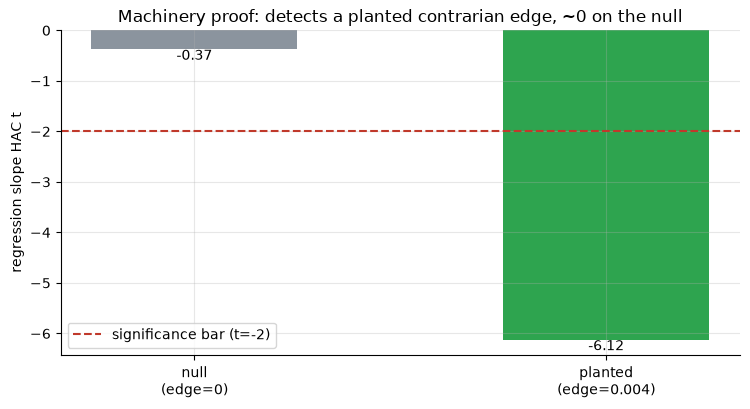

null t=-0.37 (~0)   planted t=-6.12 (<< -2)


In [2]:
de,_ = data.synthetic_weekly(edge=R['syn_edge'], seed=360)
de = de.assign(ret=de['ret'].shift(-1)).dropna()
dn,_ = data.synthetic_weekly(edge=0.0, seed=360)
dn = dn.assign(ret=dn['ret'].shift(-1)).dropna()
te = st.predictive_regression(de)['tstat']; tn = st.predictive_regression(dn)['tstat']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['null\n(edge=0)', f'planted\n(edge={R["syn_edge"]})'], [tn, te], color=[GREY, GREEN], width=.5)
ax.axhline(-2, ls='--', c=RED, label='significance bar (t=-2)')
for i,v in enumerate([tn,te]): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.set_ylabel('regression slope HAC t'); ax.set_title('Machinery proof: detects a planted contrarian edge, ~0 on the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null t={tn:+.2f} (~0)   planted t={te:+.2f} (<< -2)')

> 💡 In plain words: with a real contrarian edge in the data the slope *t* is **-6.1**; with none it's **-0.37** (≈0). So when the real tape comes back flat, that's a property of the *market*, not a broken test.

### 4b · The signal on the real tape -- right direction, no significance

Next-week SPY return by prior-exposure regime, with HAC *t*; then the predictive regression. The contrarian prediction is low > high and a negative slope.

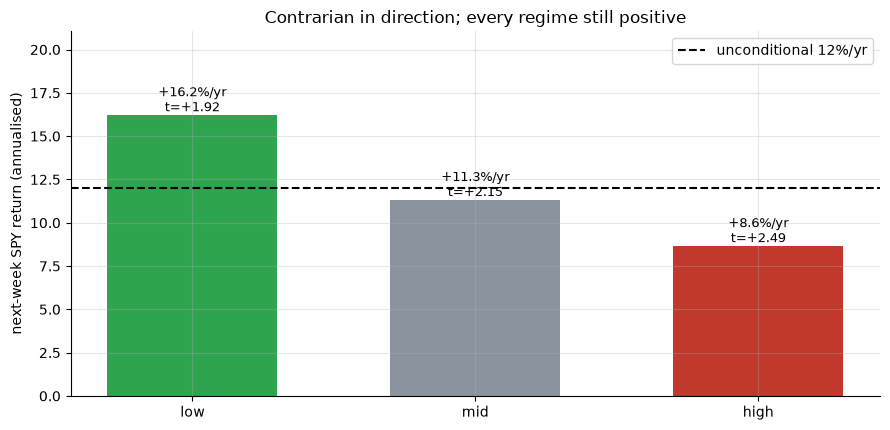

low=+16.2%/yr  high=+8.6%/yr  gap=+7.6 pp/yr
predictive slope: -0.040%/sd  HAC t=-0.40  R2=0.03%  n=1040
long-short: +2.52%/yr  HAC t=+0.81


In [3]:
rs = st.regime_summary(PANEL)
reg = st.predictive_regression(PANEL)
yrs = [rs.loc[k,'mean_ann']*100 for k in ('low','mid','high')]
ts  = [rs.loc[k,'tstat'] for k in ('low','mid','high')]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
bars = ax.bar(['low','mid','high'], yrs, color=[GREEN, GREY, RED], width=.6)
ax.axhline(R['uncond_yr'], ls='--', c='k', label=f"unconditional {R['uncond_yr']:.0f}%/yr")
for b,v,t in zip(bars,yrs,ts): ax.annotate(f'{v:+.1f}%/yr\nt={t:+.2f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('next-week SPY return (annualised)'); ax.set_ylim(0, max(yrs)*1.3)
ax.set_title('Contrarian in direction; every regime still positive'); ax.legend()
plt.tight_layout(); plt.show()
print(f"low={yrs[0]:+.1f}%/yr  high={yrs[2]:+.1f}%/yr  gap={yrs[0]-yrs[2]:+.1f} pp/yr")
print(f"predictive slope: {reg['beta']*100:+.3f}%/sd  HAC t={reg['tstat']:+.2f}  R2={reg['r2']*100:.2f}%  n={reg['n']}")
ls = st.summarize(st.regime_spread(PANEL)); print(f"long-short: {ls['mean']*5200:+.2f}%/yr  HAC t={ls['tstat']:+.2f}")

> 💡 In plain words: the gap is the contrarian one (+7.6 pp/yr), but the long-short HAC **t = +0.81** and the regression slope **t = -0.40** (R² ≈ 0.03%) are nowhere near the *t* ≥ 2 bar. Exposure explains essentially **none** of next-week variance. H₁ holds in sign, fails in strength → **Signal WEAK**, exactly as the literature (Fisher-Statman; Brown-Cliff) would predict.

### 4c · Tradability -- the overlay loses to buy-and-hold

Net-of-cost equity curve of the contrarian overlay (sit out the all-in regime) against dividend-reinvested buy-and-hold on the same SPY total-return index.

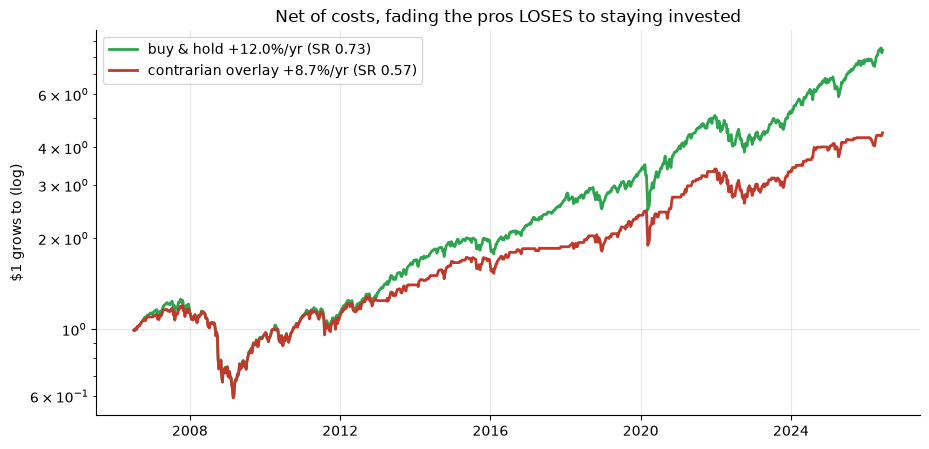

overlay NET +8.68%/yr  SR=+0.57  in-market 67% of weeks
buy & hold  +12.04%/yr  SR=+0.73


In [4]:
ov = st.timing_overlay(PANEL, one_way_bps=5.0)
s_net = st.summarize(ov['net']); s_bh = st.summarize(ov['bh'])
eq_ov = (1+ov['net']).cumprod(); eq_bh = (1+ov['bh']).cumprod()
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2,
        label=f"buy & hold {s_bh['mean']*5200:+.1f}%/yr (SR {s_bh['sharpe']*np.sqrt(52):.2f})")
ax.plot(eq_ov.index, eq_ov.values, c=RED, lw=2,
        label=f"contrarian overlay {s_net['mean']*5200:+.1f}%/yr (SR {s_net['sharpe']*np.sqrt(52):.2f})")
ax.set_yscale('log'); ax.set_ylabel('$1 grows to (log)')
ax.set_title('Net of costs, fading the pros LOSES to staying invested'); ax.legend()
plt.tight_layout(); plt.show()
print(f"overlay NET {s_net['mean']*5200:+.2f}%/yr  SR={s_net['sharpe']*np.sqrt(52):+.2f}  in-market {(ov['pos']>0).mean()*100:.0f}% of weeks")
print(f"buy & hold  {s_bh['mean']*5200:+.2f}%/yr  SR={s_bh['sharpe']*np.sqrt(52):+.2f}")

> 💡 In plain words: the overlay nets **+8.7%/yr** (SR 0.57) vs buy-and-hold **+12.0%/yr** (SR 0.73). It is in-market 67% of weeks and still loses, because the weeks it sits out -- the all-in regime -- are the bull-market core. Even the *high-sentiment* weeks earn a positive return; there is nothing to harvest by avoiding them. **H₂ rejected → Tradability MIRAGE.**

### 4d · Stability -- direction everywhere, significance nowhere robust

Split into three eras: the low > high ordering should persist (a real direction) even as the *t*-stats wander (a weak magnitude).

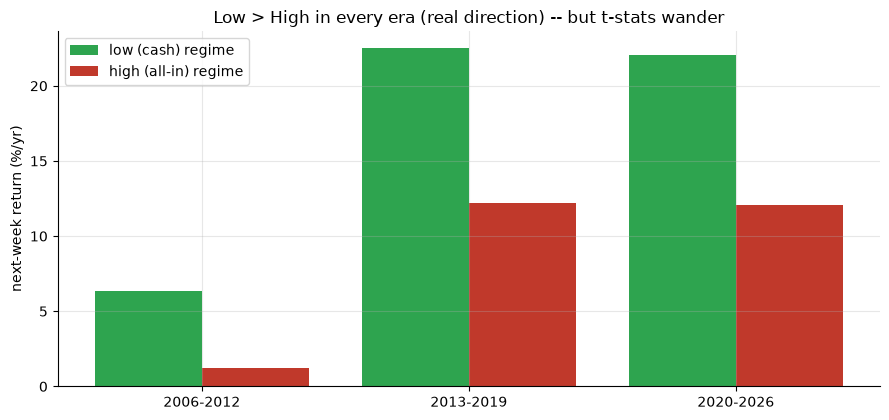

2006-2012: low=  +6.3%/yr (t=+0.34)  high=  +1.2%/yr (t=+0.17)
2013-2019: low= +22.5%/yr (t=+2.28)  high= +12.2%/yr (t=+2.57)
2020-2026: low= +22.0%/yr (t=+1.37)  high= +12.0%/yr (t=+1.54)


In [5]:
rows = []
for lab,a,b in [('2006-2012','2006','2012'),('2013-2019','2013','2019'),('2020-2026','2020','2026')]:
    sub = PANEL[a:b]; r = st.regime_summary(sub)
    rows.append((lab, r.loc['low','mean_ann']*100, r.loc['low','tstat'],
                 r.loc['high','mean_ann']*100, r.loc['high','tstat']))
labs = [x[0] for x in rows]; x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, [x[1] for x in rows], .4, color=GREEN, label='low (cash) regime')
ax.bar(x+.2, [x[3] for x in rows], .4, color=RED, label='high (all-in) regime')
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('next-week return (%/yr)')
ax.set_title('Low > High in every era (real direction) -- but t-stats wander'); ax.legend()
plt.tight_layout(); plt.show()
for lab,ly,lt,hy,ht in rows: print(f'{lab}: low={ly:+6.1f}%/yr (t={lt:+.2f})  high={hy:+6.1f}%/yr (t={ht:+.2f})')

> 💡 In plain words: low beats high in **all three** eras -- the contrarian *direction* is robust. But the low-regime *t* clears 2 only in 2013-2019; the rest of the time it's indistinguishable from the unconditional drift. A stable sign with an unstable, sub-2 magnitude is the textbook profile of a **WEAK** signal, not a real one.

## 5 · The verdict

- **Signal `WEAK`** -- contrarian direction is real and stable (low +16.2%/yr vs high +8.6%/yr in every era) but long-short HAC **t = +0.81**, slope **t = -0.40**, R² ≈ 0.03%. Literature supports the sign, this tape can't certify the magnitude; current-vintage series ⇒ upper bound.
- **Tradability `MIRAGE`** -- overlay **+8.7%/yr** vs buy-and-hold **+12.0%/yr**, net of 5 bps. Sitting out the all-in regime skips the bull-market core; the edge never pays for the missed upside.
- **Pros smarter than retail? `NOT SUPPORTED`** -- identical weak/untradeable profile to the AAII individual-investor survey. Professional *positioning* is no more bankable than retail *opinion*.

## 6 · Could you trade it? -- why it fails, structurally

The failure isn't bad luck; it's mechanical. Manager exposure is **trend-following**, so the all-in regime *coincides* with strong markets. Bucket forward returns finely by exposure and the relationship is flat-to-mildly-negative with no exploitable cliff:

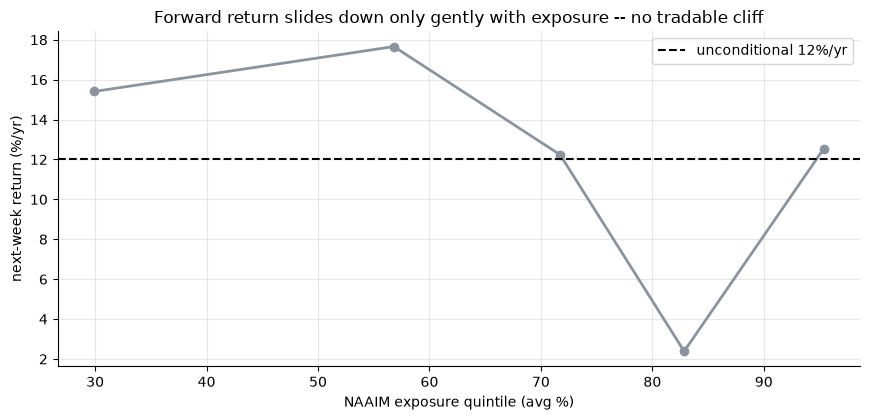

exposure quintile centers: ['30', '57', '72', '83', '95']
next-week %/yr        : ['+15', '+18', '+12', '+2', '+13']


In [6]:
p = PANEL.copy()
qs = np.quantile(p['naaim'], np.linspace(0,1,6))
p['bucket'] = np.clip(np.digitize(p['naaim'], qs[1:-1]), 0, 4)
centers = [p.loc[p['bucket']==k,'naaim'].mean() for k in range(5)]
fwd = [p.loc[p['bucket']==k,'ret'].mean()*5200 for k in range(5)]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(centers, fwd, 'o-', c=GREY, lw=2)
ax.axhline(R['uncond_yr'], ls='--', c='k', label=f"unconditional {R['uncond_yr']:.0f}%/yr")
ax.set_xlabel('NAAIM exposure quintile (avg %)'); ax.set_ylabel('next-week return (%/yr)')
ax.set_title('Forward return slides down only gently with exposure -- no tradable cliff')
ax.legend(); plt.tight_layout(); plt.show()
print('exposure quintile centers:', [f'{c:.0f}' for c in centers])
print('next-week %/yr        :', [f'{v:+.0f}' for v in fwd])

> 💡 In plain words: there's no exposure level above which returns turn *negative* -- the slope is gentle and never crosses zero. A contrarian needs a regime where fading pays *more than it costs in forgone upside*, and on this tape that regime doesn't exist. The only sizing that would have 'worked' (heavy in 2009/2020 cash extremes) is visible only with hindsight.

## 7 · Going further

- **The crowd-vs-pros bench.** Line this up against [257 -- AAII](../../257-aaii-sentiment/) (retail), [261 -- put/call](../../261-put-call-ratio/) (options) and [260 -- margin-debt](../../260-margin-debt/) (leverage): four sentiment gauges, four WEAK / MIRAGE verdicts. The interesting result is the *non-difference* -- pros don't beat retail as a contrarian tell.
- **Combine, don't isolate.** Test whether NAAIM *adds* to a momentum/trend baseline (orthogonalise exposure against trailing returns first), rather than as a standalone timer -- the trend-following confound is the prime suspect.
- **Vintage.** Rebuild on a point-in-time archive of the weekly print (if obtainable) to see how much of even this weak edge is revision-driven.

*The reproducible core is offline and deterministic; the real tape is the free, public NAAIM weekly spreadsheet joined to SPY total return. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*